This is a Jupyter notebook to simulate and animate a rolling disk under the no-slipping condition. SymPy is used to derive Euler's equations of motion (EoMs) for the disk. The EoMs are numerically solved using the odeint package from SciPy. The simulation results will be presented in 3D animation using Matplotlib.

In [1]:
%matplotlib widget
from sympy import symbols, lambdify, Matrix, solve, cos
from sympy.physics.mechanics import dynamicsymbols, init_vprinting
from sympy.physics.mechanics import ReferenceFrame, Point, inertia
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from matplotlib.animation import FuncAnimation
init_vprinting()

## Defining the disk's geometry

The figure below shows a two-dimensional disk of radius $\text{r}$ and mass $\text{m}$ to be considered. The center of mass is denoted as $\text{G}$ and its contact point with the floor is given as $\text{P}$. In addition to a space-fixed reference frame N, we define rotating reference frames Y, L and R each associated with Euler angle ($\psi, \theta, \phi$) rotation that follows the ZXZ convention. In the figure only L and N basis vectors are depicted where a lowercase bold letter with a hat represents a unit basis vector. (Examples: $\boldsymbol{\hat{n}_x}, \boldsymbol{\hat{n}_y}, \boldsymbol{\hat{n}_z}$ for the space-fixed frame) The basis vector $\boldsymbol{\hat{l}_y}$ is aligned with the line segment $\overline{GP}$ that connects the disk's center of mass and contact point.
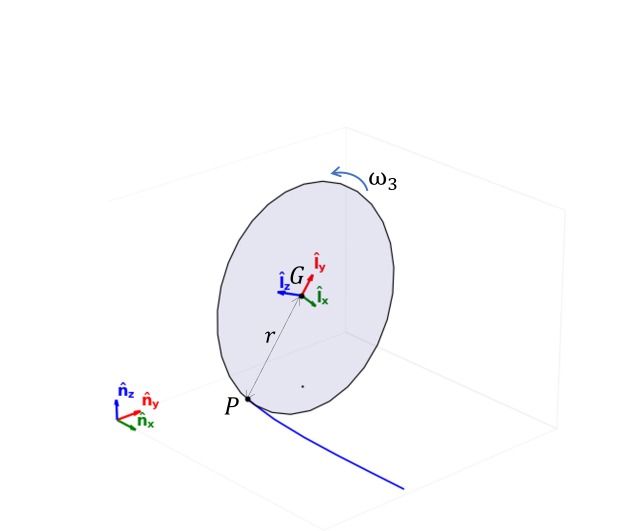

In [2]:
# Symbols for variables and parameters 
m, r, g = symbols('m r g') #disc's mass, radius and gravity acceleration
# forces exerted to the disk through its contact point with the floor
f_1, f_2, f_3 = symbols('f_1 f_2 f_3') 
# principal moments of inertia of the disk
I_1, I_3 = symbols('I_1 I_3' ) 

# Euler angles and thier 1st & 2nd order time derivatives
psi, theta, phi= dynamicsymbols('psi theta phi')
psi_dot = dynamicsymbols('psi',1) 
theta_dot = dynamicsymbols('theta',1) 
phi_dot = dynamicsymbols('phi',1) 
psi_ddot = dynamicsymbols('psi',2) 
theta_ddot = dynamicsymbols('theta',2) 
phi_ddot = dynamicsymbols('phi',2) 

# angular velocities of rotating frames
omega_1, omega_2, omega_3 = dynamicsymbols('omega_1 omega_2 omega_3') # R-frame
omicron_1, omicron_2, omicron_3 = dynamicsymbols('omicron_1 omicron_2 omicron_3') # L-frame

# mass center's horizontal position and first order derivative vector components
x1, x2, = dynamicsymbols('x1 x2')
x1_dot = dynamicsymbols('x1', 1)
x2_dot = dynamicsymbols('x2', 1)

# mass center's velocity
v_1, v_2, v_3 = dynamicsymbols('v_1 v_2 v_3')

# define reference frames (Euler 313)
N = ReferenceFrame('N') # inertia frame
Y = N.orientnew('Y', 'Axis', (psi, N.z)) # precession
L = Y.orientnew('L','Axis', (theta,Y.x)) # nutation
R = L.orientnew('R', 'Axis', (phi,L.z))  # spinning

## Deriving the disk's equations of motion
The angular velocity of the frame L observed from the space-fixed frame N is denoted as $^N\boldsymbol{\Omega}^L$ and that of the frame R as $^N\boldsymbol{\Omega}^R$, both are expressed with the L-frame basis vectors:
$$
\begin{align}
^N\boldsymbol{\Omega}^L =& \omicron_1\boldsymbol{\hat{l}_x} + \omicron_2\boldsymbol{\hat{l}_y} + \omicron_3\boldsymbol{\hat{l}_z} \tag{1a}\\
^N\boldsymbol{\Omega}^R =& \omega_1\boldsymbol{\hat{l}_x} + \omega_2\boldsymbol{\hat{l}_y} + \omega_3\boldsymbol{\hat{l}_z}, \tag{2a}
\end{align}
$$
and also described in terms of Euler angles ($\psi, \theta, \phi$) as below:
$$
\begin{align}
^N\boldsymbol{\Omega}^L =& \dot{\theta}\boldsymbol{\hat{l}_x} + \sin \theta \dot{\psi} \boldsymbol{\hat{l}_y} + \cos\theta\dot{\psi} \boldsymbol{\hat{l}_z}\tag{1b}\\
^N\boldsymbol{\Omega}^R =& \dot{\theta}\boldsymbol{\hat{l}_x} + \sin \theta \dot{\psi} \boldsymbol{\hat{l}_y} + (\cos\theta\dot{\psi}+\dot{\phi}) \boldsymbol{\hat{l}_z}.\tag{2b}
\end{align}
$$
Comparing the equations (1a) to (2b) we have:
$$
\begin{align}
\omega_1=\omicron_1 = \dot{\theta}\\
\omega_2 = \omicron_2 = \sin \theta \dot{\psi} \tag{3}\\
\omega_3= \omicron_3+\dot{\phi} = \cos\theta\dot{\psi}+\dot{\phi},
\end{align}
$$
and rewrite (1a) as below:
$$
^N\boldsymbol{\Omega}^L = \omega_1\boldsymbol{\hat{l}_x} + \omega_2\boldsymbol{\hat{l}_y} + \omicron_3\boldsymbol{\hat{l}_z}. \tag{1c}
$$
(1b) and (2b) can be obtained with SymPy as in the cells [3] and [4].

In [3]:
L.ang_vel_in(N).express(L)

In [4]:
R.ang_vel_in(N).express(L)

The mass center $\boldsymbol{G}$'s equation of translational motion is given by: 
$$
m\frac{^N{d{\boldsymbol{V_G}}}}{dt} = \boldsymbol{F}-mg\boldsymbol{\hat{n}_z} \tag{4}\
$$
where $\boldsymbol{V_G}$ is the velocity of the mass center of the disk, $\boldsymbol{F}$ is reactional force acting on the disk through the contact point $\boldsymbol{P}$, and each given as:
$$\boldsymbol{V_G}=v_1\boldsymbol{\hat{l}_x}+v_2\boldsymbol{\hat{l}_y}+v_3\boldsymbol{\hat{l}_z}\tag{5}$$
$$\boldsymbol{F}=f_x\boldsymbol{\hat{l}_x}+f_y \boldsymbol{\hat{l}_y}+f_z\boldsymbol{\hat{l}_z}.\tag{6}$$

Please note that in (4) "N" at the upper left-hand side of the time-derivative means that the derivative is done in the space-fixed frame N.

Using (1c) and (5), the left-hand side of (4) is calculated as:
$$
\begin{align}
m\frac{^N{d{\boldsymbol{V_G}}}}{dt} ={}& m(\frac{^L{d{\boldsymbol{V_G}}}}{dt}+ ^N\boldsymbol{\Omega}^L\times \boldsymbol{V_G})\\
=& m  (\dot{v_1}\boldsymbol{\hat{l}_x}+\dot{v_2}\boldsymbol{\hat{l}_y}+\dot{v_3}\boldsymbol{\hat{l}_z}) +(\omega_1\boldsymbol{\hat{l}_x} + \omega_2\boldsymbol{\hat{l}_y} + \omicron_3\boldsymbol{\hat{l}_z}) \times (v_1\boldsymbol{\hat{l}_x}+v_2\boldsymbol{\hat{l}_y}+v_3\boldsymbol{\hat{l}_z}) \\
=& m(\dot{v_1}+\omega_2 v_3-\omicron_3v_2)\boldsymbol{\hat{l}_x}+ m(\dot{v_2}+\omicron_3v_1-\omega_1 v_3)\boldsymbol{\hat{l}_y}+ m(\dot{v_3}+\omega_1 v_2-\omega_2 v_1)\boldsymbol{\hat{l}_z}.\tag{7}\\
\end{align}
$$

The velocity of the contact point $\boldsymbol{V}_P$, combination of $\boldsymbol{V}_G$ and velocity due to the disk's rotation, is given by:
$$
\boldsymbol{V_P} = \boldsymbol{V_G} + ^N\boldsymbol{\Omega}^R \times (-r)\boldsymbol{\hat{l}_y} \tag{8}
$$
The "rolling without slipping" condition implies $\boldsymbol{V_P}=0$, thus
$$
\begin{align}
\boldsymbol{V}_G =& ^N\boldsymbol{\Omega}^R \times r\boldsymbol{\hat{l}_y}\\
    =& (\omega_1\boldsymbol{\hat{l}_x} + \omega_2\boldsymbol{\hat{l}_y} + \omega_3\boldsymbol{\hat{l}_z})\times r\boldsymbol{\hat{l}_y}\\
    =& r(\omega_1\boldsymbol{\hat{l}_z}- \omega_3\boldsymbol{\hat{l}_x} )\tag{9}
\end{align}
$$

and now we have the L-basis vector elements of $\boldsymbol{V_G}$ as follows:
$$
\begin{align}
v_1&=-r\omega_3\\
v_2&=0\\ \tag{10}
v_3&=r\omega_1
\end{align}
$$
Entering (6), (7) and (10) into (4) we have:
$$
\begin{align}
m r (\omega_{1} \omega_{2} - \dot{\omega}_{3})=& f_{1} \\
- m r (\omega_{1}^2 + \omega_{3} o_{3}) =& f_{2} - g m \sin\theta \tag{11}\\ 
m r (\omega_{3} \omega_{2} + \dot{\omega}_{1}) =& f_{3} - g m \cos{\theta},
\end{align}
$$

In [5]:
# define the angular velocities of both L and R frames 
N_w_L=omega_1*L.x+omega_2*L.y+omicron_3*L.z
N_w_R=omega_1*L.x+omega_2*L.y+omega_3*L.z
# Mass center velocity
L_V_G=v_1*L.x+v_2*L.y+v_3*L.z 
# left hand side of the equation of translational motion
LHS=m*L_V_G.dt(L)+m*N_w_L.cross(L_V_G) # L_V_G.dt(N) will give the same result but expressed in terms of the Euler angles
# contact force
F=f_1*L.x+f_2*L.y+f_3*L.z
# external force
F_ext=-m*g*N.z
# equations of translational motion
eq_trl=(LHS-F-F_ext).to_matrix(L) 
# constraint: rolling without slipping 
csrt=(L_V_G-N_w_R.cross(r*L.y)).to_matrix(L)
# VG components to be expressed in the angular velocities 
v_rpl = solve([csrt[0], csrt[1], csrt[2]],(v_1, v_2, v_3))
# translational equations of motion expressed in terms of angular velocities
eq_trl=eq_trl.xreplace(v_rpl)
eq_trl

⎡                              ∂                   ⎤
⎢          -f₁ + m⋅r⋅ω₁⋅ω₂ + m⋅──(-r⋅ω₃)           ⎥
⎢                              ∂t                  ⎥
⎢                                                  ⎥
⎢                     ⎛      2          ⎞     d    ⎥
⎢-f₂ + g⋅m⋅sin(θ) + m⋅⎝- r⋅ω₁  - r⋅ω₃⋅ο₃⎠ + m⋅──(0)⎥
⎢                                             dt   ⎥
⎢                                                  ⎥
⎢                                     ∂            ⎥
⎢    -f₃ + g⋅m⋅cos(θ) + m⋅r⋅ω₂⋅ω₃ + m⋅──(r⋅ω₁)     ⎥
⎣                                     ∂t           ⎦

Rotation of the disk is described with Euler equations which can be written as:
$$
\frac{^N{d{\boldsymbol{H}}}}{dt}=\frac{^L{d{\boldsymbol{H}}}}{dt} + ^N\boldsymbol{\Omega}^L \times \boldsymbol{H} = \boldsymbol{\tau}, \tag{12}
$$

where $\boldsymbol{H}$ is the angular momentum and $\boldsymbol{\tau}$ is the torque about its mass center. 

$\boldsymbol{H}$ is given by:

$$
\boldsymbol{H} = I_1\omega_1\boldsymbol{\hat{l}_x} +I_1\omega_2\boldsymbol{\hat{l}_y}+I_3\omega_3\boldsymbol{\hat{l}_z} \tag{13}
$$

where $I_1$, $I_3$ are the principal moments of inertia of the body. 

The left-hand side of (12) becomes:
$$
\begin{align}
\frac{^N{d{\boldsymbol{H}}}}{dt} =& I_1\dot{\omega}_1\,\boldsymbol{\hat{l}_x} +I_1\dot{\omega}_2\,\boldsymbol{\hat{l}_y}+I_3\dot{\omega}_3\,\boldsymbol{\hat{l}_z}+(\omega_1\boldsymbol{\hat{l}_x} + \omega_2\boldsymbol{\hat{l}_y} + \omicron_3\boldsymbol{\hat{l}_z}) \times (I_1\omega_1\boldsymbol{\hat{l}_x} +I_1\omega_2\boldsymbol{\hat{l}_y}+I_3\omega_3\boldsymbol{\hat{l}_z} ) \\ 
=& (I_1\dot{\omega}_1\,-I_1\omega_2\omicron_3+I_3\omega_3\omega_2)\boldsymbol{\hat{l}_x} +  (I_1\dot{\omega}_2+I_1\omega_1\omicron_3-I_3\omega_3\omega_1)\boldsymbol{\hat{l}_y}+I_3\dot{\omega}_3\boldsymbol{\hat{l}_z}\tag{14}
\end{align}
$$
Also the torque $\boldsymbol{\tau}$ is calcurated as:
$$
\begin{align}
\boldsymbol{\tau} =& (-r\boldsymbol{\hat{l}_y})\times\boldsymbol{F}\\ =& -r f_3\boldsymbol{\hat{l}_x}+ r f_1\boldsymbol{\hat{l}_z} \tag{15}
\end{align}
$$ 
Rearranging (14) and (15) and expressing the equations in terms of the L-basis vectors we have:
$$
\begin{align}
I_1\dot{\omega}_1\,-I_1\omega_2\omicron_3+I_3\omega_3\omega_2 =& \, -r f_3 \\
I_1\dot{\omega}_2+I_1\omega_1\omicron_3-I_3\omega_3\omega_1 =& \, 0 \\
I_3\dot{\omega}_3 =& r f_1\tag{16}\\
\end{align}
$$
By entering the first and third equations of (11) in (16), we can delete both unknown foces $f_1$ and $f_3$:
$$
\begin{align}
(I_1+m r^2)\dot{\omega}_1\,+(I_3+m r^2)\omega_3\omega_2 -I_1\omega_2\omicron_3=& - g m r\cos{\theta} \\
I_1\dot{\omega}_2+I_1\omega_1\omicron_3-I_3\omega_3\omega_1 =& \, 0 \\
(I_3+ mr^2)\dot{\omega}_3 - mr^2 \omega_{1} \omega_{2}=& \,0 \tag{17}\\
\end{align}
$$
SymPy can produce the same result as (17) with the following codes:

In [6]:
# angular momentum of the disk
I=inertia(L, I_1, I_1, I_3)
H_ang_momt = I.dot(N_w_R).express(L)
# time derivative of angular momentum wrt the inertial frame 
eq_h =H_ang_momt.dt(L)+N_w_L.cross(H_ang_momt)
eq_h_mtrx=eq_h.to_matrix(L)
# torque about the mass center
trq=(-r*L.y).cross(F)
trq.to_matrix(L)

⎡-f₃⋅r⎤
⎢     ⎥
⎢  0  ⎥
⎢     ⎥
⎣f₁⋅r ⎦

In [7]:
# rotational motion equation
eq=eq_h_mtrx-trq.to_matrix(L).simplify()
# force terms appeared in the translational EoM
F_rpl = solve([eq_trl[0], eq_trl[1], eq_trl[2]],(f_1, f_2, f_3))
# to be entered in the rotational EoM
eq=eq.xreplace(F_rpl)
eq

⎡                                 ⎛                           ∂       ⎞⎤
⎢-I₁⋅ω₂⋅ο₃ + I₁⋅ω₁̇ + I₃⋅ω₂⋅ω₃ + r⋅⎜g⋅m⋅cos(θ) + m⋅r⋅ω₂⋅ω₃ + m⋅──(r⋅ω₁)⎟⎥
⎢                                 ⎝                           ∂t      ⎠⎥
⎢                                                                      ⎥
⎢                     I₁⋅ω₁⋅ο₃ + I₁⋅ω₂̇ - I₃⋅ω₁⋅ω₃                      ⎥
⎢                                                                      ⎥
⎢                           ⎛              ∂        ⎞                  ⎥
⎢                 I₃⋅ω₃̇ - r⋅⎜m⋅r⋅ω₁⋅ω₂ + m⋅──(-r⋅ω₃)⎟                  ⎥
⎣                           ⎝              ∂t       ⎠                  ⎦

The results obtained above can be further expressed with the codes below in Euler angles ($\psi, \theta, \phi$):

In [8]:
# angular velocities of L and R frames to be expressed in the Euler angles
eu_ang=(N_w_R-R.ang_vel_in(N)).to_matrix(L)
eu_ang_rpl = solve([eu_ang[0], eu_ang[1], eu_ang[2]],(omega_1, omega_2, omega_3))
eu_ang_rpl[omicron_3] = cos(theta)*psi_dot
# and theequation of motion as well
eq=eq.xreplace(eu_ang_rpl).simplify()
eq

⎡               2                                                              ↪
⎢  I₁⋅sin(2⋅θ)⋅ψ̇                                                               ↪
⎢- ────────────── + I₁⋅θ̈ + I₃⋅(cos(θ)⋅ψ̇ + φ̇)⋅sin(θ)⋅ψ̇ + m⋅r⋅(g⋅cos(θ) + r⋅(cos ↪
⎢        2                                                                     ↪
⎢                                                                              ↪
⎢                   I₁⋅(sin(θ)⋅ψ̈ + cos(θ)⋅ψ̇⋅θ̇) + I₁⋅cos(θ)⋅ψ̇⋅θ̇ - I₃⋅(cos(θ)⋅ψ̇  ↪
⎢                                                                              ↪
⎣        I₃⋅(-sin(θ)⋅ψ̇⋅θ̇ + cos(θ)⋅ψ̈ + φ̈) - m⋅r⋅(-r⋅(-sin(θ)⋅ψ̇⋅θ̇ + cos(θ)⋅ψ̈ + φ̈ ↪

↪                           ⎤
↪                           ⎥
↪ (θ)⋅ψ̇ + φ̇)⋅sin(θ)⋅ψ̇ + r⋅θ̈)⎥
↪                           ⎥
↪                           ⎥
↪ + φ̇)⋅θ̇                    ⎥
↪                           ⎥
↪ ) + r⋅sin(θ)⋅ψ̇⋅θ̇)         ⎦

To locate the position of the mass center in animation, we want to make first $\boldsymbol{V}_G$ expressed in the N-frame and look at its components. SymPy will do this job and I put the result:
$$\boldsymbol{V}_G= r(\sin\psi\sin\theta\,\dot{\theta}-\cos\psi(\cos\theta\dot{\psi}+\dot{\phi}))\boldsymbol{\hat{n}_x}
-r(\cos\psi\sin\theta\,\dot{\theta}+\sin\psi(\cos\theta\dot{\psi}+\dot{\phi}))\boldsymbol{\hat{n}_y}+r\cos\theta\,\dot{\theta}\boldsymbol{\hat{n}_z}\tag{18}
$$

In [9]:
# obtain the mass center's velocity using the Euler angles
N_V_G=(R.ang_vel_in(N).cross(r*L.y)).express(N)
N_V_G

The component of $\boldsymbol{\hat{n}_z}$ is integrable and the vertical position $x_3$ of the mass center is given by:
$$x_3=\int r\cos \theta \, \dot{\theta} dt = r\,\sin\theta + const \tag{19}$$
The constant of integration is determined as zero. The positon vector of the mass center is given by:
$$\boldsymbol{R}_G= x_1\boldsymbol{\hat{n}_x}+ x_2\boldsymbol{\hat{n}_y}+r\sin\theta\boldsymbol{\hat{n}_z}\tag{20} $$

$x_1$ and $x_2$ will be determined numerically with the following equations:
$$
\begin{align}
{x_i}(t+1) =& x_i(t)+ \Delta x_i(t)\\
           =& x_i(t)+ v_i(\psi,\theta,\dot{\psi},\dot{\theta},\dot{\phi},t),  \tag{21}                                                
\end{align}
$$  
where $i=1,2$ and $t$ stands for discrete time.

If we introduce a state vector $\,\boldsymbol{u} = [\dot{\psi},\dot{\theta},\dot{\phi},\psi,\theta,\phi,x_1,x_2]^T$, the whole set of equations can be expressed in a form $M(t,\boldsymbol{u})\dot{\boldsymbol{u}} =f(t,\boldsymbol{u})$ and rearranging it for $\dot{\boldsymbol{u}}$ we have:

$$\dot{\boldsymbol{u}} =M(t,\boldsymbol{u})^{-1}f(t,\boldsymbol{u}).\tag{22}$$
Regarding $\dot{\boldsymbol{u}}$, we know $[\dot{x}_1,\dot{x}_2]^T$ from (18). The remaining $[\ddot{\psi},\ddot{\theta},\ddot{\phi}]^T$ are calcurated with SymPy as follows:

In [10]:
u_dot = Matrix([psi_ddot, theta_ddot, phi_ddot])
M=eq.jacobian(u_dot)
f_repl={psi_ddot:0, theta_ddot:0, phi_ddot:0}
f_term=(-1)*eq.xreplace(f_repl)
u_dot_eu = M.inv().trigsimp()@f_term
u_dot_eu

⎡                         -2⋅I₁⋅cos(θ)⋅ψ̇⋅θ̇ + I₃⋅(cos(θ)⋅ψ̇ + φ̇)⋅θ̇               ↪
⎢                         ──────────────────────────────────────               ↪
⎢                                       I₁⋅sin(θ)                              ↪
⎢                                                                              ↪
⎢             2                                                                ↪
⎢I₁⋅sin(2⋅θ)⋅ψ̇                                                                 ↪
⎢────────────── - I₃⋅(cos(θ)⋅ψ̇ + φ̇)⋅sin(θ)⋅ψ̇ - m⋅r⋅(g⋅cos(θ) + r⋅(cos(θ)⋅ψ̇ + φ̇ ↪
⎢      2                                                                       ↪
⎢───────────────────────────────────────────────────────────────────────────── ↪
⎢                                               2                              ↪
⎢                                       I₁ + m⋅r                               ↪
⎢                                                                              ↪
⎢                

## Numerical solution
Now we have a set of first order differential equations with 8 unknown variables: $\dot{\psi},\dot{\theta},\dot{\phi}, \psi, \theta, \phi, \dot{x}_1,\dot{x}_2$. To obtain numerical solutions of the equations with the ODEINT package, "lamdification" of the symbolic equations  will follow. The codes given below follow a standard procedure to numerically solve ordinary differential equaitons with odeint. Also, point objects are created to express the disk's mass center, contact point and rim. Once objects are created, as their relative positions are defined in a given reference frame, their coordinates can be easily converted and lamdified in the N reference frame for 3D animation.

In [11]:
# lamdify the equations for numerical calculation
args_bdy = (theta, psi_dot, theta_dot, phi_dot, I_1, I_3, m, r,g)
psi_ddot_f = lambdify(args_bdy, u_dot_eu[0], "numpy")
theta_ddot_f = lambdify(args_bdy, u_dot_eu[1], "numpy")
phi_ddot_f = lambdify(args_bdy, u_dot_eu[2], "numpy")

N_V_G_=N_V_G.to_matrix(N)
args_G = (psi, theta, psi_dot, theta_dot, phi_dot, r)
N_V_G_x_f = lambdify(args_G, N_V_G_[0], "numpy")
N_V_G_y_f = lambdify(args_G, N_V_G_[1], "numpy")

# Define a function for the odeint solver
def dSdt(S, t):
    psi_dot, theta_dot, phi_dot, psi, theta, phi, x1, x2 = S
    return [
        psi_ddot_f(theta, psi_dot, theta_dot, phi_dot, I_1, I_3, m, r,g),
        theta_ddot_f(theta, psi_dot, theta_dot, phi_dot, I_1, I_3, m, r,g),
        phi_ddot_f(theta, psi_dot, theta_dot, phi_dot, I_1, I_3, m, r,g),
        psi_dot,
        theta_dot,
        phi_dot,
        N_V_G_x_f (psi, theta, psi_dot, theta_dot, phi_dot, r),
        N_V_G_y_f(psi, theta, psi_dot, theta_dot, phi_dot, r),
    ]
# define disk's geometry
G = Point('G') # disk's mass center
P = G.locatenew('P', -r*L.y) # Disk's contact point defined relative to the mass center
P.set_vel(N, 0) # contact point's instantaneous velocity is zero
# keep record of the contact point's 
P_pos=P.pos_from(G).to_matrix(N)
P_coords = lambdify([psi,theta,r], P_pos)

# disk's circumference
E = G.locatenew('E', r*R.y)
disk_circ = E.pos_from(G).to_matrix(N)
disk_circ_f = lambdify([psi,theta,phi,r], disk_circ)

# calculate the disk's circumferential point coordinates
def calc_disk(x_, y_, z_, psi_,theta_): #x_,y_,z_: mass center
    disk_circ_coords=[]
    phi_s = np.linspace(0, 2*np.pi,30)
    for ph in phi_s:
        temp=disk_circ_f(psi_,theta_,ph,r).T[0,:]+np.array([x_,y_,z_])
        disk_circ_coords.append(temp)
    return disk_circ_coords

#  Physical parameters:
m = 5.0                          #  kg
g = 9.81                       #  m/s^2
r = 0.5                        #  m
I_1 = 1/4*m*r**2            #  kg-m^2
I_3 = 1/2*m*r**2            #  kg-m^2

#  Simulation parameters:
tf = 20.0                 #  s
dt = 0.1                #  s
# Intial condition
psidot0 = 0                    #  rad/s
thetadot0 = 0                  #  rad/s
phidot0 = np.pi                #  rad/s
psi0 = 0*(np.pi/180)           #  rad
theta0 = 85*(np.pi/180)        #  rad
phi0 = 80*(np.pi/180)          #  rad
x10 = 0                        #  m
x20 = 0                        #  m
Y0 = [psidot0, thetadot0, phidot0, psi0, theta0, phi0, x10,x20]

# time span
t = np.arange(0, tf, dt)

# solve the differential equation  
ans = odeint(dSdt, y0=Y0, t=t)

# contact point's position
x, y, z = P_coords(ans[:,3],ans[:,4],r)

## Animating the rolling disk
The codes below follow a standard procedure to animate a 3d object using matplotlib. At each step of the animation function "animate(i)" the cartesian coordinates of the points are calcurated from the ODEINT result for the Euler angles.

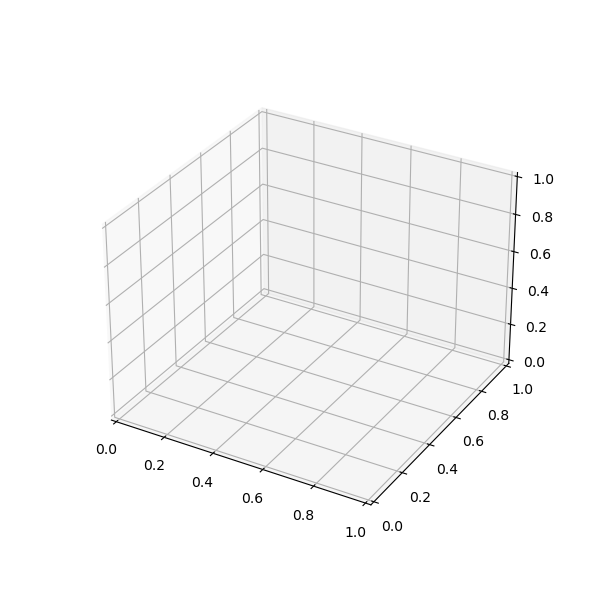

In [12]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection ='3d')
#ax.set_box_aspect((1,1,1))
line_prop = {
    'color': 'black',
    'marker': 'o',
    'markerfacecolor': 'black',
    'markersize': 1,
}
l=30/1000

def animate(i):
    plt.cla()
    ax.plot(ans[i,6], ans[i,7], r*np.sin(ans[i,4]), 'ro', markersize=2) # mass center
    ax.plot(ans[:i,6]+x[0][:i], ans[:i,7]+y[0][:i],0, color ='blue') # contact point's path of rotation
    verts0 = calc_disk(ans[i,6], ans[i,7], r*np.sin(ans[i,4]),ans[i,3],ans[i,4])
    ax.add_collection3d(Poly3DCollection([verts0],edgecolor='k', facecolor='#000080',alpha=0.5))
    ax.set_xlim((-3.0, 3.0))
    ax.set_ylim((-2.0, 4.0))
    ax.set_zlim((0, 4))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
ani = FuncAnimation(fig, animate, len(t),interval=100)
#ani.save('rolling_disk.gif', writer='pillow', fps=10)

# References

江沢洋, 中村孔一, 山本義隆 (著) 　演習詳解　力学　第２版 (ちくま学芸文庫) ISBN-13: 978-4480511188

https://rotations.berkeley.edu/the-rolling-disk/